<a href="https://colab.research.google.com/github/Ravi-Poddar26/missing-values/blob/master/H_M_V(4).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # Random Imputer
 fill random value at the place of null value

 it is most use in lenear algorithm

 this demerit is use must place all test data at server.

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = sns.load_dataset('titanic') # Removed usecols to avoid KeyError with internal Seaborn processing
df = df[['age', 'fare', 'survived']] # Now select the desired columns after loading the full dataset
df.head()

,age,fare,survived
0,22.0,7.2500,0
1,38.0,71.2833,1
2,26.0,7.9250,1
3,35.0,53.1000,1
4,35.0,8.0500,0


In [ ]:
df.isnull().mean()*100

,0
age,19.86532
fare,0.00000
survived,0.00000


In [ ]:
x = df.drop(columns=['survived'])
y = df['survived']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)

In [ ]:
X_train['Age_imputer'] = X_train['age'].copy()
X_test['Age_imputer'] = X_test['age'].copy()

In [ ]:
X_train.head()

,age,fare,Age_imputer
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0


In [ ]:
X_train.loc[X_train['Age_imputer'].isnull(), 'Age_imputer'] = X_train['age'].dropna().sample(X_train['Age_imputer'].isnull().sum(), random_state=42).values
X_test.loc[X_test['Age_imputer'].isnull(), 'Age_imputer'] = X_train['age'].dropna().sample(X_test['Age_imputer'].isnull().sum(), random_state=42).values

In [ ]:
X_train

,age,fare,Age_imputer
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,18.0
493,71.0,49.5042,71.0
527,NaN,221.7792,21.0


/tmp/ipython-input-4145725061.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['age'], label='Original', hist = False)
/tmp/ipython-input-4145725061.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age_imputer'], label='Imputed', hist = False)


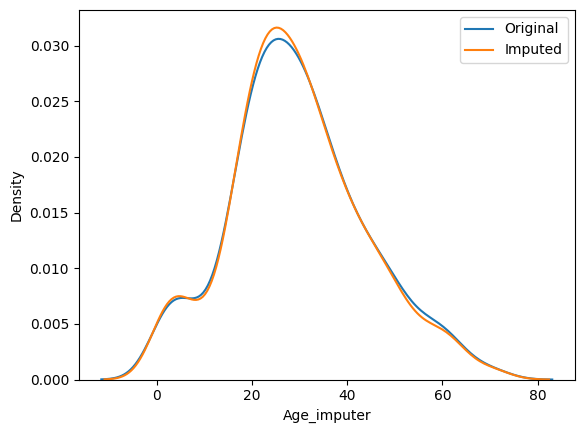

In [ ]:
sns.distplot(X_train['age'], label='Original', hist = False)
sns.distplot(X_train['Age_imputer'], label='Imputed', hist = False)
plt.legend()
plt.show()

In [ ]:
print('Orifinal Variable variance: ', X_train['age'].var())
print('Imputed Variable variance: ', X_train['Age_imputer'].var())
#

Orifinal Variable variance:  204.3495133904614
Imputed Variable variance:  200.02896637747125


In [ ]:
X_train[['fare', 'age', 'Age_imputer']].cov()

,fare,age,Age_imputer
fare,2368.246832,71.512440,53.259863
age,71.512440,204.349513,204.349513
Age_imputer,53.259863,204.349513,200.028966


In [ ]:
X_train[['fare', 'age', 'Age_imputer']].corr()

,fare,age,Age_imputer
fare,1.000000,0.095814,0.077382
age,0.095814,1.000000,1.000000
Age_imputer,0.077382,1.000000,1.000000


<Axes: >

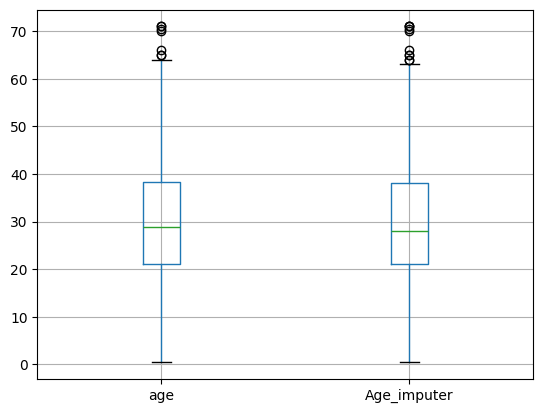

In [ ]:
X_train[['age', 'Age_imputer']].boxplot()

In [ ]:
sampled_value = X_train['age'].dropna().sample(X_train['Age_imputer'].isnull().sum(), random_state=42)

In [ ]:
da = pd.read_csv('https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/main/day38-missing-indicator/house-train.csv')

In [ ]:
data = da[['GarageQual','FireplaceQu','SalePrice']]

In [ ]:
data.head()

,GarageQual,FireplaceQu,SalePrice
0,TA,NaN,208500
1,TA,TA,181500
2,TA,TA,223500
3,TA,Gd,140000
4,TA,TA,250000


In [ ]:
data.isnull().mean()*100

,0
GarageQual,5.547945
FireplaceQu,47.260274
SalePrice,0.000000


In [ ]:
x = data
y = data['SalePrice']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(data.drop(columns=['SalePrice']), data['SalePrice'], test_size=0.2)

In [ ]:
X_train['GarageQual_imputer'] = X_train['GarageQual'].copy()
X_test['GarageQual_imputer'] = X_test['GarageQual'].copy()

X_train['FireplaceQu_imputer'] = X_train['FireplaceQu'].copy()
X_test['FireplaceQu_imputer'] = X_test['FireplaceQu'].copy()

In [ ]:
X_train.sample(5)

,GarageQual,FireplaceQu,GarageQual_imputer,FireplaceQu_imputer
1280,TA,NaN,TA,NaN
1401,TA,TA,TA,TA
74,TA,NaN,TA,NaN
1217,TA,NaN,TA,NaN
1002,TA,Gd,TA,Gd


In [ ]:
X_train.loc[X_train['GarageQual_imputer'].isnull(), 'GarageQual_imputer'] = X_train['GarageQual_imputer'].dropna().sample(X_train['GarageQual_imputer'].isnull().sum(), random_state=42).values
X_test.loc[X_test['GarageQual_imputer'].isnull(), 'GarageQual_imputer'] = X_train['GarageQual_imputer'].dropna().sample(X_test['GarageQual_imputer'].isnull().sum(), random_state=42).values

X_train.loc[X_train['FireplaceQu_imputer'].isnull(), 'FireplaceQu_imputer'] = X_train['FireplaceQu_imputer'].dropna().sample(X_train['FireplaceQu_imputer'].isnull().sum(), random_state=42).values
X_test.loc[X_test['FireplaceQu_imputer'].isnull(), 'FireplaceQu_imputer'] = X_test['FireplaceQu_imputer'].dropna().sample(X_test['FireplaceQu_imputer'].isnull().sum(), random_state=42).values


In [ ]:
temp = pd.concat(
    [
        X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
        X_train['GarageQual_imputer'].value_counts() / len(X_train),
    ],
    axis=1
)
temp.columns = ['Original', 'Imputed']
temp
#

,Original,Imputed
TA,0.955776,0.957192
Fa,0.032491,0.031678
Gd,0.008123,0.007705
Po,0.002708,0.002568
Ex,0.000903,0.000856


In [ ]:
temp = pd.concat(
    [
        X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
        X_train['FireplaceQu_imputer'].value_counts() / len(X_train),
    ],
    axis=1
)
temp.columns = ['Original', 'Imputed']
temp
#

,Original,Imputed
Gd,0.479675,0.482021
TA,0.416260,0.413527
Fa,0.045528,0.047089
Ex,0.029268,0.028253
Po,0.029268,0.029110


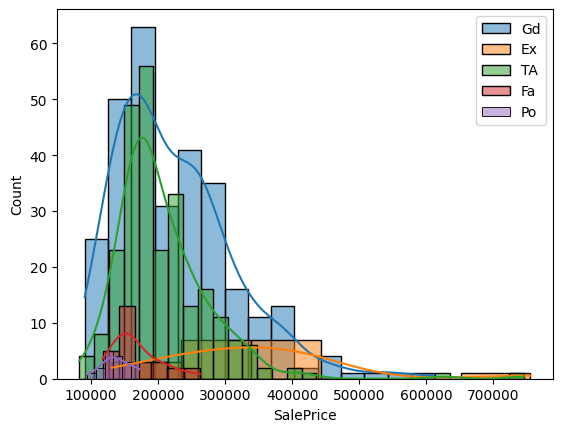

In [ ]:
for category in X_train['FireplaceQu'].dropna().unique():
  # Select SalePrice from y_train for the current FireplaceQu category in X_train
  indices_for_category = X_train[X_train['FireplaceQu'] == category].index
  sns.histplot(y_train.loc[indices_for_category], label=category, kde=True)
plt.legend()
plt.show()

In [ ]:
for category in X_train['FireplaceQu_Imputed'].dropna().unique():
  # Select SalePrice from y_train for the current FireplaceQu category in X_train
  indices_for_category = X_train[X_train['FireplaceQu_Imputed'] == category].index
  sns.histplot(y_train.loc[indices_for_category], label=category, kde=True)
plt.legend()
plt.show()

KeyError: 'FireplaceQu_Imputed'